In [15]:
import cv2
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import pickle
from PIL import Image
from IPython.display import display

In [16]:
data_dir = './seg'
hists_hsv = []
hists_rgb = []
for subdir, dirs, files in os.walk(data_dir):
  for file in tqdm(files):
    image_path = os.path.join(subdir, file)
    image = cv2.imread(image_path)

    # HSV
    image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist0_hsv = cv2.calcHist([image_hsv], [0], None, [180], [0, 180])
    hist1_hsv = cv2.calcHist([image_hsv], [1], None, [256], [0, 256])
    hist2_hsv = cv2.calcHist([image_hsv], [2], None, [256], [0, 256])
    hist_hsv = np.concatenate((hist0_hsv, hist1_hsv, hist2_hsv))
    cv2.normalize(hist_hsv, hist_hsv, 0, 1, cv2.NORM_MINMAX)
    hists_hsv.append((image_path, hist_hsv))

    # RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hist0_rgb = cv2.calcHist([image_rgb], [0], None, [256], [0, 256])
    hist1_rgb = cv2.calcHist([image_rgb], [1], None, [256], [0, 256])
    hist2_rgb = cv2.calcHist([image_rgb], [2], None, [256], [0, 256])
    hist_rgb = np.concatenate((hist0_rgb, hist1_rgb, hist2_rgb))
    cv2.normalize(hist_rgb, hist_rgb, 0, 1, cv2.NORM_MINMAX)
    hists_rgb.append((image_path, hist_rgb))

with open('data_hsv.pkl', 'wb') as file:
    pickle.dump(hists_hsv, file)

with open('data_rgb.pkl', 'wb') as file:
    pickle.dump(hists_rgb, file)

0it [00:00, ?it/s]
100%|██████████| 2404/2404 [01:35<00:00, 25.30it/s] 


In [17]:
def process_image(image):
  # HSV
  image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
  hist0_hsv = cv2.calcHist([image_hsv], [0], None, [180], [0, 180])
  hist1_hsv = cv2.calcHist([image_hsv], [1], None, [256], [0, 256])
  hist2_hsv = cv2.calcHist([image_hsv], [2], None, [256], [0, 256])
  input_hist_hsv = np.concatenate((hist0_hsv, hist1_hsv, hist2_hsv))
  cv2.normalize(input_hist_hsv, input_hist_hsv, 0, 1, cv2.NORM_MINMAX)

  # RGB
  image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  hist0_rgb = cv2.calcHist([image_rgb], [0], None, [256], [0, 256])
  hist1_rgb = cv2.calcHist([image_rgb], [1], None, [256], [0, 256])
  hist2_rgb = cv2.calcHist([image_rgb], [2], None, [256], [0, 256])
  input_hist_rgb = np.concatenate((hist0_rgb, hist1_rgb, hist2_rgb))
  cv2.normalize(input_hist_rgb, input_hist_rgb, 0, 1, cv2.NORM_MINMAX)

  return input_hist_hsv, input_hist_rgb

In [18]:
# Hàm tìm ảnh tương đồng (HSV)
def top_10_similar_hsv(img_hist, loaded_data, method=cv2.HISTCMP_CORREL):
  similar_images = []

  for path, hist in loaded_data:
      similarity = cv2.compareHist(img_hist, hist, method)
      similar_images.append((path, similarity))

  if (method == cv2.HISTCMP_BHATTACHARYYA or method == cv2.HISTCMP_CHISQR):
      similar_images.sort(key=lambda x: x[1], reverse=False)
  else:
      similar_images.sort(key=lambda x: x[1], reverse=True)

  return similar_images[:10]

In [19]:
# Hàm tìm ảnh tương đồng (RGB)
def top_10_similar_rgb(img_hist, loaded_data, method=cv2.HISTCMP_CORREL):
  similar_images = []

  for path, hist in loaded_data:
      similarity = cv2.compareHist(img_hist, hist, method)
      similar_images.append((path, similarity))

  if (method == cv2.HISTCMP_BHATTACHARYYA or method == cv2.HISTCMP_CHISQR):
      similar_images.sort(key=lambda x: x[1], reverse=False)
  else:
      similar_images.sort(key=lambda x: x[1], reverse=True)

  return similar_images[:10]

In [20]:
# Đọc hist đã lưu
with open('data_hsv.pkl', 'rb') as file:
    loaded_data_hsv = pickle.load(file)

with open('data_rgb.pkl', 'rb') as file:
    loaded_data_rgb = pickle.load(file)

In [ ]:
def visualize_results(query_path, search_results, method_name, color_space):
  if not search_results:
      print(f"Không tìm thấy kết quả so khớp nào trong không gian {color_space}.")
      return

  num_results = len(search_results)
  top_k = num_results

  plt.figure(figsize=(18, 8))
  plt.suptitle(f"Top {top_k} ảnh tương đồng nhất (Không gian {color_space}, Phương pháp: {method_name})", fontsize=16)

  query_image = cv2.imread(query_path)
  if query_image is None:
      print(f"Lỗi: Không đọc được ảnh truy vấn tại {query_path}")
      return

  query_image = cv2.cvtColor(query_image, cv2.COLOR_BGR2RGB)

  plt.subplot(2, 6, 1)
  plt.imshow(query_image)
  plt.title("Ảnh truy vấn (Query)")
  plt.axis('off')

  for i, (path, similarity_score) in enumerate(search_results):
      ax_index = i + 2

      if ax_index > 12:
          break

      plt.subplot(2, 6, ax_index)

      result_image = cv2.imread(path)
      if result_image is None:
            print(f"Lỗi: Không đọc được ảnh kết quả tại {path}")
            continue

      result_image = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

      label = os.path.basename(os.path.dirname(path))
      image_name = os.path.basename(path)


      plt.imshow(result_image)
      plt.title(f"{label}\n{image_name}\nSim: {similarity_score:.4f}")
      plt.axis('off')

  plt.tight_layout() 
  plt.show()

In [ ]:
#CHẠY CHƯƠNG TRÌNH TRUY VẤN
query_image_path = './seg_test/forest/21921.jpg'

if not os.path.exists(query_image_path):
    print(f"Lỗi: Không tìm thấy ảnh truy vấn tại đường dẫn: {query_image_path}")
else:
    # Tính histogram cho ảnh truy vấn
    img_query = cv2.imread(query_image_path)
    input_hist_hsv, input_hist_rgb = process_image(img_query)

    method_name = "Correlation (CORREL)"
    # Mã số của phương pháp (cv2.HISTCMP_CORREL: Tương đồng; cv2.HISTCMP_BHATTACHARYYA: Khoảng cách)
    comparison_method = cv2.HISTCMP_CORREL


Truy vấn sử dụng không gian HSV...


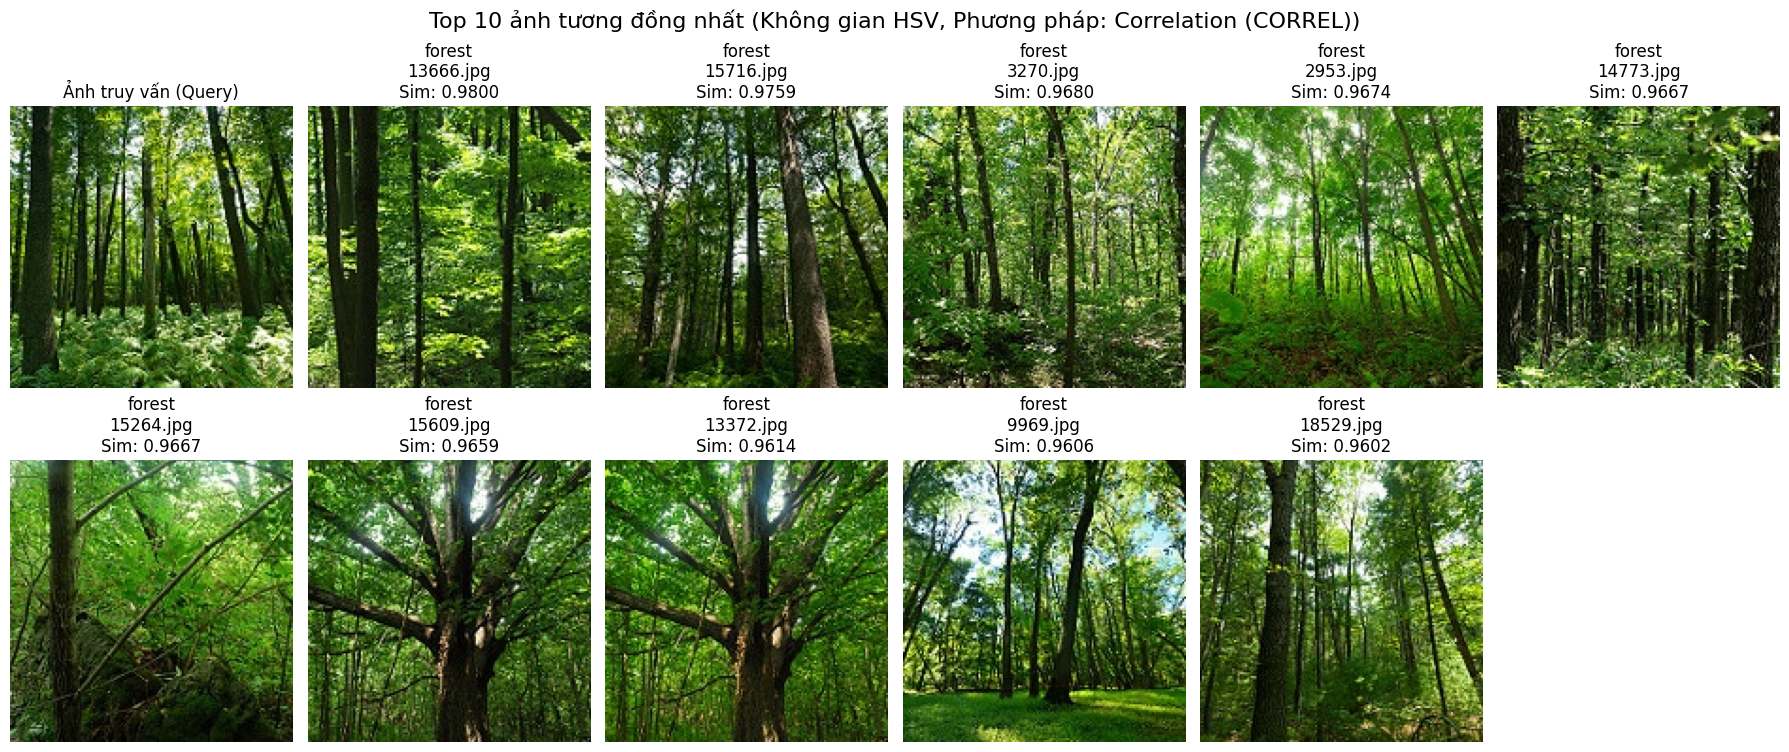

In [ ]:
# --- THỰC HIỆN TRUY VẤN HSV ---
print(f"Truy vấn sử dụng không gian HSV...")

results_hsv = top_10_similar_hsv(
    input_hist_hsv.astype(np.float32),
    loaded_data_hsv,
    method=comparison_method
)

visualize_results(query_image_path, results_hsv, method_name, "HSV")

Truy vấn sử dụng không gian RGB...


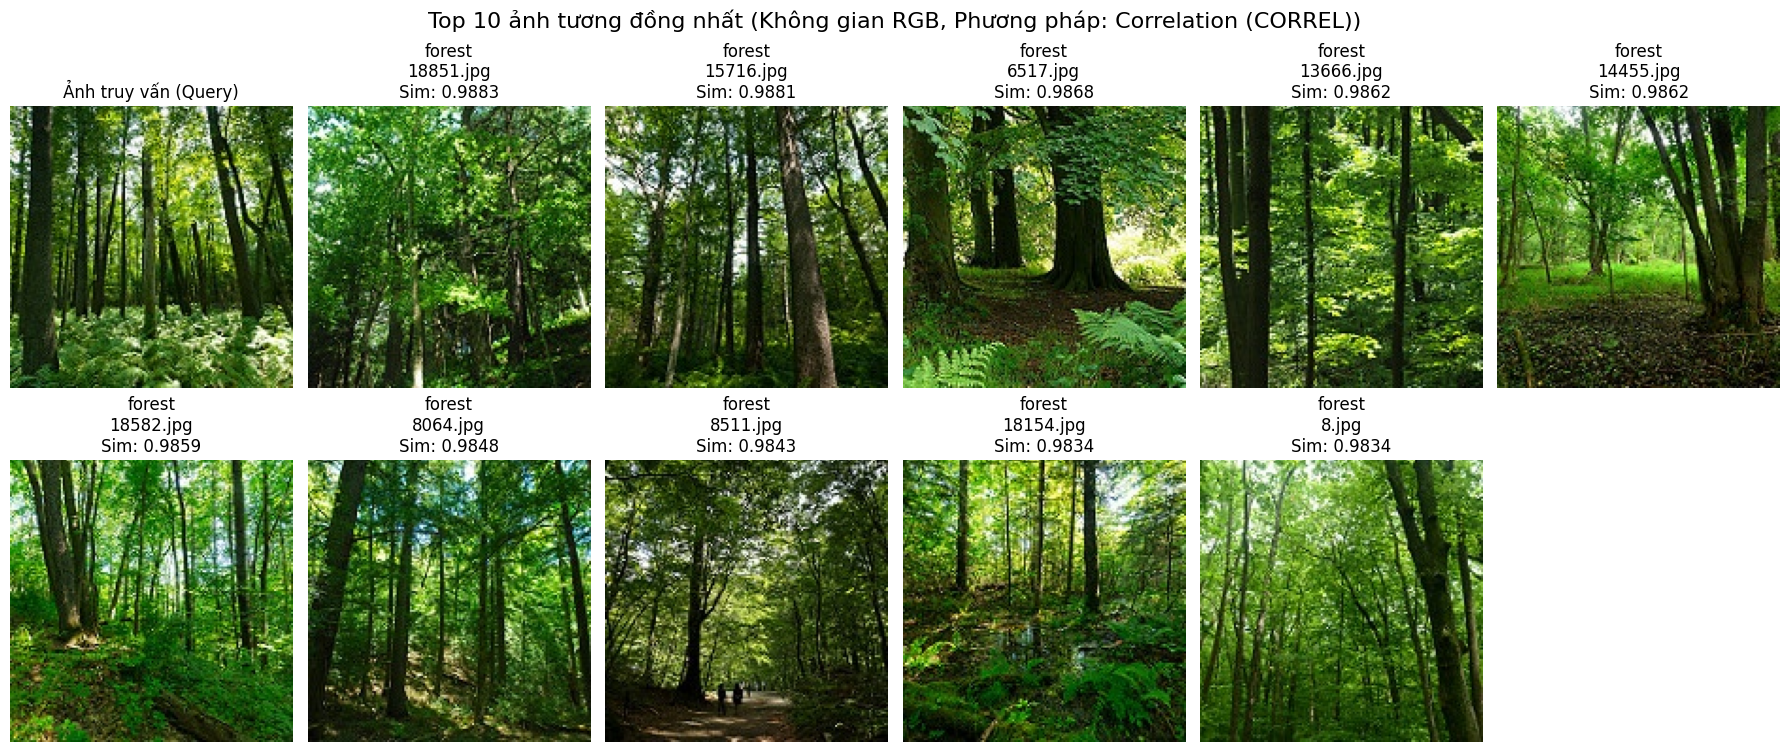

In [ ]:
# --- THỰC HIỆN TRUY VẤN RGB ---
print(f"Truy vấn sử dụng không gian RGB...")

# Sử dụng hàm đã định nghĩa
results_rgb = top_10_similar_rgb(
    input_hist_rgb.astype(np.float32),
    loaded_data_rgb,
    method=comparison_method
)

# Hiển thị kết quả RGB
visualize_results(query_image_path, results_rgb, method_name, "RGB")